# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [ ] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [ ] change OS to 1/10,
- [ ] 1/10 OS and scf bop
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset

In [4]:
DS = Dataset('Cr-Co-W')

In [5]:
DS.BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Co_pv,Cr_pv,W_sv,EF,Phase
index,,,,,,,,,,,,,,,,,,,,,
Cr_pv10Co_pv14.C36-BABBA.FM,bulk C36-BABBA.FM,11.509371 A,-7.818095,155.630160 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,,10,14,0,24.0,0.583333,0.416667,0.000000,0.244599,C36
Co_pv14W_sv16.sigma-AABBA.FM,bulk sigma-AABBA.FM,14.022487 A,-9.879896,163.400685 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,,14,16,0,30.0,0.466667,0.000000,0.533333,0.309269,sigma
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM,bulk C36-ABBBC.FM,13.785739 A,-8.408861,167.511402 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,W_sv,4,14,6,24.0,0.583333,0.166667,0.250000,0.515037,C36
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM,bulk C36-BAACB.FM,13.591446 A,-8.839783,168.089154 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,W_sv,8,10,6,24.0,0.416667,0.333333,0.250000,0.497308,C36
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM,bulk C36-ABABC.FM,13.729286 A,-8.774383,169.848261 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,W_sv,8,10,6,24.0,0.416667,0.333333,0.250000,0.562708,C36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv13Co_pv16.chi-ABAB.FM,bulk chi-ABAB.FM,11.038602 A,-8.007061,308.802257 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,,13,16,0,29.0,0.551724,0.448276,0.000000,0.133997,chi
Cr_pv2W_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.374534 A,-11.936445,315.105053 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,,2,11,0,13.0,0.000000,0.153846,0.846154,0.487269,mu
Cr_pv20Co_pv4.C36-BAAAA.FM,bulk C36-BAAAA.FM,11.844381 A,-8.804312,318.529958 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,,20,4,0,24.0,0.166667,0.833333,0.000000,0.291364,C36


# Targets

Text(0.5, 0, '$V_0$')

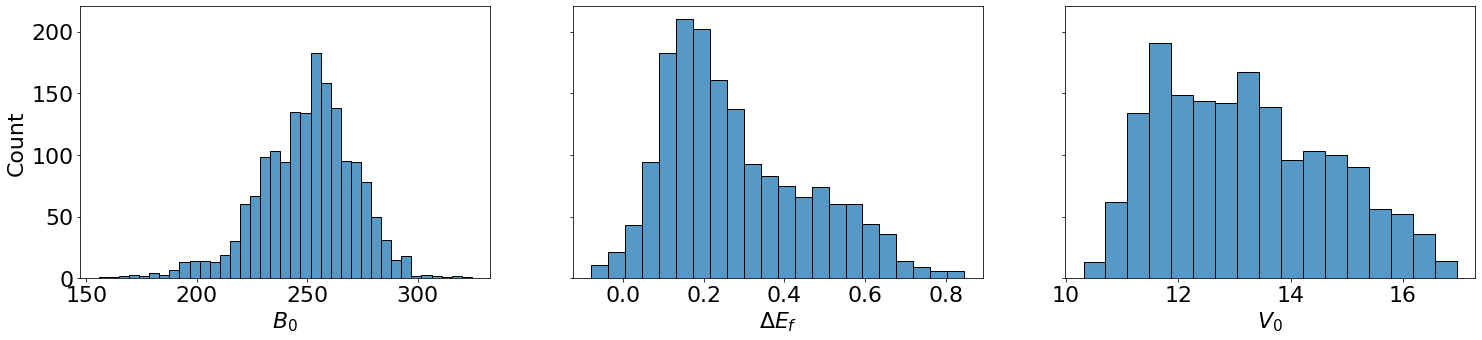

In [6]:
fig, ax = plt.subplots(1,3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS['EF'], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel('$\Delta E_f$')
ax[2].set_xlabel('$V_0$')

# Machine Learning 

In [7]:
from Tools.DatasetTools.MLConveniences import *

In [8]:
resultslocation = DS.resultslocation

## Feature sets

In [9]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [10]:
Features['Canonical BOP']

,Structure,Mag,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,...,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Cr_pv10Co_pv14.C36-BABBA.FM,3,0,-79.665926,-11.738799,-10.197699,0.000000,0.000000,0.000000,-1.541099,2.153192,...,0.000000,0.000000,0.000000,0.644704,1.081734,1.156284,0.000000,0.000000,0.000000,0.901329
Co_pv14W_sv16.sigma-AABBA.FM,10,0,-124.647841,-12.360477,-8.276995,0.000000,-3.325676,-0.757805,0.000000,2.193422,...,0.000000,0.903237,0.224615,0.000000,1.224173,1.311936,0.000000,1.187306,1.155464,0.000000
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM,3,0,-86.818936,-12.298502,-10.818432,0.000000,0.000000,0.000000,-1.480070,2.362917,...,0.000000,0.000000,0.000000,0.675372,1.081730,1.156280,0.000000,0.000000,0.000000,0.901326
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM,3,0,-99.349900,-12.328621,-10.423365,0.000000,0.000000,0.000000,-1.905256,2.220308,...,0.000000,0.000000,0.000000,0.665089,1.081731,1.096157,0.000000,0.000000,0.000000,1.050804
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM,3,0,-96.559077,-12.330026,-10.427581,0.000000,0.000000,0.000000,-1.902445,2.220308,...,0.000000,0.000000,0.000000,0.680012,1.081731,1.103530,0.000000,0.000000,0.000000,1.035868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv13Co_pv16.chi-ABAB.FM,6,0,-96.178640,-11.436131,-8.325034,-2.226709,0.000000,0.000000,-0.884388,1.895321,...,0.576278,0.000000,0.000000,0.237722,1.251703,1.437268,1.179083,0.000000,0.000000,1.006202
Cr_pv2W_sv11.mu-BBABB.FM,9,0,-82.678009,-12.474105,-3.956485,0.000000,-6.811599,-0.917225,-0.788796,2.289023,...,0.000000,0.294869,0.300221,0.299222,1.093709,1.221533,0.000000,0.974009,0.817863,0.996110
Cr_pv20Co_pv4.C36-BAAAA.FM,3,0,-105.620687,-11.460702,-4.355887,0.000000,0.000000,0.000000,-7.104816,1.854433,...,0.000000,0.000000,0.000000,0.598308,1.081733,1.156285,0.000000,0.000000,0.000000,0.901326
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM,3,0,-90.449132,-12.718387,-10.619216,0.000000,0.000000,0.000000,-2.099172,2.362917,...,0.000000,0.000000,0.000000,0.686115,1.081730,1.096154,0.000000,0.000000,0.000000,1.050805


In [11]:
Features.keys()

dict_keys(['atomic', 'dataset', 'Pyscal', 'Canonical BOP', 'Projections BOP', 'Projections OS BOP', 'Projections sOS BOP', 'dataset + Canonical BOP', 'dataset + Projections BOP', 'dataset + Projections OS BOP', 'dataset + Projections sOS BOP'])

## BOP features with and without CP averages

In [12]:
def clean_CNAVS(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_CN)')
    else:
        return features

In [13]:
def clean_zeros(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_0$)')
    else:
        return features

In [14]:
def notyetclean(name:str):
    return ('BOP' in name) and ('CNAV' not in name) and ('Zeros' not in name)

In [15]:
# Features.update({name+' no CNAV': clean_CNAVS(name, features) for name, features in Features.items() if notyetclean(name) } )

In [16]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [17]:
samplesplit = DS.get_samplesplit(split_random_state=200)

# Models: adjust params

In [18]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
}

In [19]:
Parameters = {
    'Kernel Ridge': {'regressor__alpha':[0.1, 0.01,0.001],
                     'regressor__kernel':['rbf', 'polynomial'], 
                     'regressor__degree': [4,5],
                     'regressor__coef0': [0.5, 1, 1.5],
                    }
}

In [20]:
samplefolds = list(DS.get_folds())

# fits

In [21]:
FittedModels = {}

In [22]:
Models

{'Kernel Ridge': Pipeline(steps=[('scaler', StandardScaler()), ('regressor', KernelRidge())])}

In [ ]:
for name, model in Models.items():
    print (name)
    progress = tqdm(Features.items())
    for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            Parameters[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        FittedModels[(name, key)] = model.fit(features, DS.target)

Kernel Ridge


  0%|          | 0/11 [00:00<?, ?it/s]

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [ ]:
best_scores = {}
for (modelname, featurename), fittedmodel in FittedModels.items():
    best_scores[(modelname, featurename)] = {'test': abs(fittedmodel.best_score_)}
best_scores = pd.DataFrame.from_dict(best_scores, orient='index')
best_scores.index = pd.MultiIndex.from_tuples(best_scores.index)
best_scores.sort_values(by='test', ascending=True, inplace=True)
best_scores.sort_index(level=0, sort_remaining=False, ascending=True, inplace=True)

In [ ]:
results = pd.DataFrame.from_dict(FittedModels[('Kernel Ridge', 'dataset + Projections OS BOP')].cv_results_)

In [ ]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [ ]:
for parameters in Parameters.values():
    for key in parameters.keys():
        print (results.groupby(by='param_'+key)['mean_test_score'].max())

In [ ]:
FittedModels[('Kernel Ridge', 'dataset + Projections OS BOP')].best_params_

In [ ]:
ax = best_scores.unstack(level=0).sort_values(by=('test','Kernel Ridge')).plot.bar()
ax.set_ylim([0,0.1])
